# Week 2 — Day 2: Probability and Distributions

Probability provides a mathematical way to describe uncertainty. Instead
of stating that an event will certainly happen or will never happen, we
measure how likely it is using a value between 0 and 1.

This notebook introduces the main probability concepts required for
machine learning. It begins with basic probability terminology and the
core probability rules, then develops conditional probability, Bayes'
theorem, and three common probability distributions.

The theoretical ideas are supported by reproducible NumPy simulations
and clearly labelled Matplotlib visualisations. Each experiment is
followed by an interpretation that compares the observed result with its
theoretical expectation.

## 1. Learning Objectives

By the end of this notebook, we will be able to:

- Define an experiment, outcome, sample space, and event.
- Calculate probability from favourable and total equally likely outcomes.
- Distinguish between theoretical and experimental probability.
- Apply the complement, addition, and multiplication rules.
- Distinguish independent events from mutually exclusive events.
- Explain and calculate conditional probability.
- Apply Bayes' theorem using a small worked example.
- Recognise uniform, binomial, and normal distributions.
- Use NumPy to simulate random experiments reproducibly.
- Interpret probability results and connect them to machine learning.

## 2. Imports and Reproducibility

This notebook uses:

- **NumPy** for numerical calculations and random simulations.
- **Matplotlib** for visualising probability distributions.

Random simulations normally produce slightly different results each time
they are run. To make this notebook reproducible, we create a NumPy
random-number generator with a fixed seed.

Using a fixed seed does not remove randomness from the statistical idea.
It fixes the pseudo-random sequence generated by the computer so that
another person can reproduce the same experiment and results.

Changing the seed may change the exact simulated values, but a
sufficiently large simulation should preserve the same general pattern.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(10)

### Setup Check

The required libraries were imported successfully, and the random-number
generator is ready.

All simulations in this notebook will use the same generator. When the
notebook is restarted and run from top to bottom, the results will be
reproduced consistently.

## 3. Why Probability Matters in Machine Learning

Machine-learning systems often make predictions under uncertainty.

For example, a classification model may estimate:

> There is an 85% probability that a customer will churn.

This value does not guarantee that the customer will leave. It represents
the model's level of confidence based on the available features and the
patterns learned from previous data.

Many prediction problems can be expressed as conditional-probability
questions:

$$
P(\text{target} \mid \text{observed features})
$$

For customer churn, this becomes:

$$
P(\text{customer churns} \mid \text{customer information})
$$

The vertical symbol $\mid$ is read as **given**.

Therefore, the second expression means:

> The probability that a customer will churn, given the available
> information about that customer.

Probability helps machine-learning models represent uncertainty, compare
possible outcomes, and make decisions based on observed evidence.

## 4. Probability Fundamentals

Probability measures how likely an event is to occur.

A probability must be between 0 and 1:

- A probability of **0** represents an impossible event.
- A probability of **1** represents a certain event.
- A probability between 0 and 1 represents uncertainty.

Before calculating probability, we need four basic terms:

| Term | Meaning | Fair-Die Example |
|---|---|---|
| Experiment | A repeatable process with an uncertain result | Rolling a die |
| Outcome | One possible result of the experiment | Rolling a 4 |
| Sample space | The set of all possible outcomes | `{1, 2, 3, 4, 5, 6}` |
| Event | One or more outcomes of interest | Rolling an even number: `{2, 4, 6}` |

When all possible outcomes are equally likely, the probability of an event
is calculated as:

$$
P(A)=
\frac{\text{number of favourable outcomes}}
{\text{total number of possible outcomes}}
$$

In this formula:

- $P(A)$ means the probability of event $A$.
- The numerator counts the outcomes that satisfy event $A$.
- The denominator counts all possible outcomes.

For a fair die, let event $A$ represent rolling an even number.

The favourable outcomes are `{2, 4, 6}`. Therefore:

$$
P(A)=\frac{3}{6}=0.5
$$

### 4.1 Calculating a Simple Probability with Python

We will represent the sample space of a fair die using a NumPy array.

Event $A$ is defined as rolling an even number. We will:

1. Identify the outcomes that satisfy the event.
2. Count the favourable outcomes.
3. Count all possible outcomes.
4. Divide the favourable count by the total count.

The result should equal 0.5 because this is a theoretical calculation
based on equally likely outcomes, not a random simulation.

In [2]:
die_sample_space = np.array([1, 2, 3, 4, 5, 6])
even_outcomes = die_sample_space[die_sample_space % 2 == 0]
favourable_outcomes_count = len(even_outcomes)
total_outcomes_count = len(die_sample_space)
probability_of_even_number = (favourable_outcomes_count / total_outcomes_count)
print("Sample space:", die_sample_space)
print("Favourable outcomes:", even_outcomes)
print("Number of favourable outcomes:", favourable_outcomes_count)
print("Total number of outcomes:", total_outcomes_count)
print(f"Probability of an even number: {probability_of_even_number:.2f}")

Sample space: [1 2 3 4 5 6]
Favourable outcomes: [2 4 6]
Number of favourable outcomes: 3
Total number of outcomes: 6
Probability of an even number: 0.50


### Interpretation

The sample space contains six equally likely outcomes, and three of them
are even numbers.

Therefore:

$$
P(\text{even number})=\frac{3}{6}=0.5
$$

This is a theoretical probability because it was calculated directly
from all possible equally likely outcomes. No die rolls were simulated.

The result does not mean that exactly half of every small group of real
die rolls must be even. A real or simulated experiment may differ from
0.5 because of random variation.

## 5. Theoretical and Experimental Probability

A **theoretical probability** is calculated from a known mathematical
model.

For a fair coin:

$$
P(\text{heads})=\frac{1}{2}=0.5
$$

An **experimental probability** is calculated from observed results:

$$
P_{\text{experimental}}(\text{heads})
=
\frac{\text{observed number of heads}}
{\text{total number of flips}}
$$

For example, if heads appears 7 times in 10 flips, the experimental
probability is:

$$
\frac{7}{10}=0.7
$$

This does not change the theoretical probability of a fair coin.
It only describes what happened in that particular experiment.

A small experiment may produce a proportion noticeably different from
0.5 because individual random outcomes have a large effect.

As the number of independent flips becomes large, the observed
proportion usually becomes more stable and tends to move closer to the
theoretical probability. This is the main intuition behind the
**law of large numbers**.

It does not mean that a finite simulation must produce exactly 0.5.

## 6. Required Coin-Flip Simulation

We will simulate 10,000 flips of a fair coin using NumPy.

The outcomes will be represented as:

- `0` = tails
- `1` = heads

Because the simulated coin is fair, the theoretical probability of heads
is:

$$
P(\text{heads})=0.5
$$

The simulation will report:

- The total number of flips.
- The observed number of heads.
- The observed number of tails.
- The observed proportion of heads.
- The theoretical probability of heads.
- The absolute difference between the observed and theoretical values.


In [3]:
number_of_flips = 10_000
theoretical_heads_probability = 0.5
coin_flips = rng.integers(
    low=0,
    high=2,
    size=number_of_flips)
heads_count = np.sum(coin_flips == 1)
tails_count = np.sum(coin_flips == 0)
heads_proportion = heads_count / number_of_flips
difference_from_theoretical_probability = abs(heads_proportion - theoretical_heads_probability)
print("Outcome representation: 0 = tails, 1 = heads")
print(f"Total number of flips: {number_of_flips:,}")
print(f"Number of heads: {heads_count:,}")
print(f"Number of tails: {tails_count:,}")
print(f"Observed proportion of heads: {heads_proportion:.4f}")
print("Theoretical probability of heads: "f"{theoretical_heads_probability:.4f}")
print("Absolute difference from theoretical probability: "f"{difference_from_theoretical_probability:.4f}")

Outcome representation: 0 = tails, 1 = heads
Total number of flips: 10,000
Number of heads: 4,980
Number of tails: 5,020
Observed proportion of heads: 0.4980
Theoretical probability of heads: 0.5000
Absolute difference from theoretical probability: 0.0020


### Interpretation

The observed proportion of heads is close to the theoretical probability
of 0.5.

The observed and theoretical values are not required to match perfectly
because this is a finite random experiment. A small imbalance between
heads and tails is normal.

The absolute difference measures how far the simulated proportion is from
the theoretical value:

$$
\text{absolute difference}
=
\left|
P_{\text{experimental}}(\text{heads})-0.5
\right|
$$

The small difference demonstrates that, across a large number of
independent fair-coin flips, the experimental proportion tends to
stabilise near the theoretical probability.

This supports the law-of-large-numbers intuition. However, it does not
mean that every set of 10,000 flips must produce exactly the same result.

It also does not prove that every physical coin is fair. Fairness is an
assumption built into this simulation.

### 6.1 Comparing Different Numbers of Flips

To examine how sample size affects experimental probability, we will
repeat the fair-coin experiment using several numbers of flips:

- 10 flips
- 100 flips
- 1,000 flips
- 10,000 flips

Small experiments may fluctuate substantially because each outcome has a
relatively large effect on the final proportion.

Larger experiments usually produce more stable proportions near 0.5.
However, the results do not have to improve in a perfectly ordered
sequence. Random variation is still present in every sample.

In [4]:
sample_sizes = [10, 100, 1_000, 10_000]
print(f"{'Number of Flips':>16}"f"{'Heads Proportion':>20}"f"{'Difference from 0.5':>22}")
for sample_size in sample_sizes:
    simulated_flips = rng.integers(low=0,high=2,size=sample_size)
    simulated_heads_proportion = np.mean(simulated_flips == 1)
    simulated_difference = abs(simulated_heads_proportion - theoretical_heads_probability)
    print(f"{sample_size:>16,}"f"{simulated_heads_proportion:>20.4f}"f"{simulated_difference:>22.4f}")

 Number of Flips    Heads Proportion   Difference from 0.5
              10              0.4000                0.1000
             100              0.4700                0.0300
           1,000              0.5100                0.0100
          10,000              0.4990                0.0010


### Interpretation

The smaller experiments may show noticeable variation because each
individual outcome has a relatively large effect on the final
proportion.

For example, one additional head changes the result of a 10-flip
experiment by:

$$
\frac{1}{10}=0.1
$$

In contrast, one additional head changes the result of a 10,000-flip
experiment by only:

$$
\frac{1}{10{,}000}=0.0001
$$

Individual outcomes therefore have a smaller effect on the final
proportion when the sample size is large.

The larger samples generally provide more stable estimates of the
theoretical probability. However, the difference from 0.5 does not have
to decrease perfectly at every step.

A smaller sample may occasionally be closer to 0.5 than a larger sample
because random variation remains present.

## 7. The Complement Rule

The complement rule calculates the probability that an event does **not**
occur.

If event $A$ represents an event of interest, then its complement,
written as $A^c$ or $\text{not }A$, contains all outcomes that are not
part of $A$.

Because an event and its complement together include every possible
outcome, their probabilities must add to 1:

$$
P(A)+P(A^c)=1
$$

Therefore:

$$
P(A^c)=1-P(A)
$$

In this formula:

- $P(A)$ is the probability that event $A$ occurs.
- $P(A^c)$ is the probability that event $A$ does not occur.
- The value 1 represents the probability of the complete sample space.

### Manual Example

Suppose a fair die is rolled once.

Let event $A$ represent rolling a 6:

$$
P(A)=\frac{1}{6}
$$

The complement represents rolling any number except 6:

$$
P(A^c)=1-\frac{1}{6}=\frac{5}{6}
$$

Therefore, the probability of not rolling a 6 is approximately 0.8333.

### 7.1 Applying the Complement Rule with Python

We will calculate the probability of not rolling a 6 on a fair die.

First, we define the probability of rolling a 6. Then we subtract that
probability from 1 to obtain the probability of its complement.

This is an exact theoretical calculation, so no random simulation is
required.

In [5]:
probability_of_rolling_six = 1 / 6
probability_of_not_rolling_six = (1 - probability_of_rolling_six)
print("Probability of rolling a 6: "f"{probability_of_rolling_six:.4f}")
print("Probability of not rolling a 6: "f"{probability_of_not_rolling_six:.4f}")
print("Check that the probabilities sum to 1: "f"{probability_of_rolling_six + probability_of_not_rolling_six:.4f}")

Probability of rolling a 6: 0.1667
Probability of not rolling a 6: 0.8333
Check that the probabilities sum to 1: 1.0000


### Interpretation

The probability of rolling a 6 is approximately 0.1667, while the
probability of not rolling a 6 is approximately 0.8333.

The two probabilities add to 1 because the two events cover every
possible outcome:

- Either the die shows 6.
- Or the die does not show 6.

These events cannot occur together, and one of them must occur.

The complement rule is especially useful when calculating the opposite
event is easier than counting the event directly.

## 8. The Addition Rule

The addition rule calculates the probability that event $A$, event $B$,
or both events occur.

In probability, the word **or** is normally inclusive. This means:

- $A$ may occur.
- $B$ may occur.
- Both $A$ and $B$ may occur.

The general addition rule is:

$$
P(A \cup B)
=
P(A)+P(B)-P(A \cap B)
$$

The symbols mean:

- $A \cup B$: event $A$ or event $B$, including their overlap.
- $A \cap B$: event $A$ and event $B$ occurring together.
- $P(A \cap B)$ is subtracted because the overlapping outcomes were
  counted once in $P(A)$ and again in $P(B)$.

### Manual Example with Overlapping Events

Suppose a fair die is rolled once.

Define:

- Event $A$: rolling an even number, `{2, 4, 6}`.
- Event $B$: rolling a number greater than 3, `{4, 5, 6}`.

Their probabilities are:

$$
P(A)=\frac{3}{6}
$$

$$
P(B)=\frac{3}{6}
$$

The events overlap at `{4, 6}`, so:

$$
P(A \cap B)=\frac{2}{6}
$$

Applying the addition rule:

$$
P(A \cup B)
=
\frac{3}{6}+\frac{3}{6}-\frac{2}{6}
=
\frac{4}{6}
$$

Therefore, the probability of rolling an even number or a number greater
than 3 is approximately 0.6667.

### 8.1 Verifying the Addition Rule with Python Sets

We will represent the die's sample space and the two events using Python
sets.

Set operations provide a clear way to represent probability events:

- `&` returns the intersection of two sets.
- `|` returns the union of two sets.

We will calculate the probabilities from the sizes of the sets and verify
that the addition-rule result matches the probability obtained directly
from the union.

In [6]:
die_outcomes = {1, 2, 3, 4, 5, 6}

event_a_even = {2, 4, 6}
event_b_greater_than_three = {4, 5, 6}

event_intersection = event_a_even & event_b_greater_than_three
event_union = event_a_even | event_b_greater_than_three

total_die_outcomes = len(die_outcomes)

probability_event_a = (len(event_a_even) / total_die_outcomes)

probability_event_b = (len(event_b_greater_than_three) / total_die_outcomes)

probability_intersection = (len(event_intersection) / total_die_outcomes)

probability_union_using_rule = (probability_event_a+ probability_event_b- probability_intersection)

probability_union_directly = (len(event_union) / total_die_outcomes)

print("Event A:", event_a_even)
print("Event B:", event_b_greater_than_three)
print("Intersection A and B:", event_intersection)
print("Union A or B:", event_union)
print(f"\nP(A): {probability_event_a:.4f}")
print(f"P(B): {probability_event_b:.4f}")
print(f"P(A and B): {probability_intersection:.4f}")
print("P(A or B) using the addition rule: "f"{probability_union_using_rule:.4f}")
print("P(A or B) calculated directly: "f"{probability_union_directly:.4f}")

Event A: {2, 4, 6}
Event B: {4, 5, 6}
Intersection A and B: {4, 6}
Union A or B: {2, 4, 5, 6}

P(A): 0.5000
P(B): 0.5000
P(A and B): 0.3333
P(A or B) using the addition rule: 0.6667
P(A or B) calculated directly: 0.6667


### Interpretation

The intersection contains `{4, 6}` because these outcomes are both even
and greater than 3.

The union contains `{2, 4, 5, 6}` because each of these values satisfies
at least one of the two events.

The probability calculated using the addition rule matches the
probability calculated directly from the union.

The intersection must be subtracted because its outcomes were included
in both $P(A)$ and $P(B)$. Without this subtraction, the outcomes 4 and 6
would be counted twice.

This example demonstrates that the addition rule correctly handles
events that overlap.

### 8.2 Mutually Exclusive Events

Two events are **mutually exclusive** when they cannot occur during the
same experiment.

For one fair-die roll, define:

- Event $A$: rolling a 1.
- Event $B$: rolling a 6.

A single die cannot show both 1 and 6 at the same time. Therefore:

$$
P(A \cap B)=0
$$

The general addition rule becomes:

$$
P(A \cup B)
=
P(A)+P(B)-0
$$

Therefore:

$$
P(A \cup B)=P(A)+P(B)
$$

For the die example:

$$
P(A \cup B)
=
\frac{1}{6}+\frac{1}{6}
=
\frac{2}{6}
=
\frac{1}{3}
$$

### 8.3 Verifying Mutually Exclusive Events

We will represent rolling a 1 and rolling a 6 as two separate events.

Their intersection should be empty, so its probability should be zero.

The union probability can therefore be calculated by adding the two
individual probabilities without subtracting any overlap.

In [7]:
event_a_roll_one = {1}
event_b_roll_six = {6}

mutually_exclusive_intersection = (
    event_a_roll_one & event_b_roll_six
)

mutually_exclusive_union = (
    event_a_roll_one | event_b_roll_six
)

probability_roll_one = (
    len(event_a_roll_one) / total_die_outcomes
)

probability_roll_six = (
    len(event_b_roll_six) / total_die_outcomes
)

probability_mutually_exclusive_intersection = (
    len(mutually_exclusive_intersection)
    / total_die_outcomes
)

probability_one_or_six = (
    probability_roll_one
    + probability_roll_six
    - probability_mutually_exclusive_intersection
)

print(
    "Intersection:",
    mutually_exclusive_intersection
)

print(
    "Union:",
    mutually_exclusive_union
)

print(
    "Probability of the intersection: "
    f"{probability_mutually_exclusive_intersection:.4f}"
)

print(
    "Probability of rolling 1 or 6: "
    f"{probability_one_or_six:.4f}"
)

Intersection: set()
Union: {1, 6}
Probability of the intersection: 0.0000
Probability of rolling 1 or 6: 0.3333


### Interpretation

The intersection is empty because rolling a 1 and rolling a 6 cannot
occur in the same die roll.

Its probability is therefore zero.

Because there is no overlap, adding the two individual probabilities
does not count any outcome twice:

$$
P(\text{1 or 6})
=
\frac{1}{6}+\frac{1}{6}
=
\frac{2}{6}
$$

The simplified addition rule applies only because these events are
mutually exclusive. For overlapping events, the intersection must still
be subtracted.

## 9. The Multiplication Rule

The multiplication rule calculates the probability that two events occur
together.

For independent events:

$$
P(A \cap B)=P(A)\times P(B)
$$

The symbols mean:

- $P(A \cap B)$: the probability that both $A$ and $B$ occur.
- $P(A)$: the probability of event $A$.
- $P(B)$: the probability of event $B$.

Two events are **independent** when the occurrence of one event does not
change the probability of the other.

### Manual Example

Suppose a fair coin is flipped twice.

Define:

- Event $A$: the first flip is heads.
- Event $B$: the second flip is heads.

The first flip does not affect the second flip, so the events are
independent.

Therefore:

$$
P(A)=0.5
$$

$$
P(B)=0.5
$$

Using the multiplication rule:

$$
P(A \cap B)
=
0.5 \times 0.5
=
0.25
$$

Thus, the theoretical probability of obtaining heads on both flips is
0.25.

### 9.1 Verifying the Multiplication Rule with a Simulation

We will simulate many pairs of fair-coin flips.

For every pair:

- The first generated value represents the first flip.
- The second generated value represents the second flip.
- `1` represents heads.
- `0` represents tails.

We will count how often both flips are heads and compare the observed
proportion with the theoretical probability of 0.25.

The simulated result should be close to 0.25, but it does not need to
match it perfectly.

In [8]:
number_of_flip_pairs = 50_000

first_flips = rng.integers(
    low=0,
    high=2,
    size=number_of_flip_pairs
)

second_flips = rng.integers(
    low=0,
    high=2,
    size=number_of_flip_pairs
)

both_heads = (
    (first_flips == 1)
    & (second_flips == 1)
)

observed_both_heads_probability = np.mean(both_heads)

theoretical_both_heads_probability = 0.5 * 0.5

difference_from_theoretical_both_heads = abs(
    observed_both_heads_probability
    - theoretical_both_heads_probability
)

print(f"Number of flip pairs: {number_of_flip_pairs:,}")

print(
    "Observed probability of two heads: "
    f"{observed_both_heads_probability:.4f}"
)

print(
    "Theoretical probability of two heads: "
    f"{theoretical_both_heads_probability:.4f}"
)

print(
    "Absolute difference: "
    f"{difference_from_theoretical_both_heads:.4f}"
)

Number of flip pairs: 50,000
Observed probability of two heads: 0.2495
Theoretical probability of two heads: 0.2500
Absolute difference: 0.0005


### Interpretation

The observed proportion of pairs containing two heads should be close to
the theoretical probability of 0.25.

A perfect match is not required because the simulation uses a finite
random sample. The absolute difference measures the remaining random
variation.

The result supports the multiplication rule for independent events:

$$
P(\text{heads on both flips})
=
P(\text{heads on the first flip})
\times
P(\text{heads on the second flip})
$$

The rule works here because the outcome of the first flip does not change
the probability of the second flip.

This result does not mean that multiplication can be used automatically
for every pair of events. Independence must be justified before using
the simplified multiplication rule.

### 9.2 Independent Events vs. Mutually Exclusive Events

Independent events and mutually exclusive events describe different
relationships.

| Concept | Meaning | Can Both Occur? | Example |
|---|---|---:|---|
| Independent events | One event does not change the probability of the other | Yes | Heads on the first and second coin flips |
| Mutually exclusive events | The events cannot occur in the same experiment | No | Rolling a 1 and rolling a 6 in one die roll |

For independent events:

$$
P(A \cap B)=P(A)P(B)
$$

For mutually exclusive events:

$$
P(A \cap B)=0
$$

These ideas should not be treated as synonyms.

If two events have positive probabilities and are mutually exclusive,
they cannot be independent. Once one event occurs, the other becomes
impossible, so its probability has changed.

## 10. Conditional Probability

Conditional probability calculates the probability of an event after
we know that another event has already occurred.

It is written as:

$$
P(A \mid B)
$$

This is read as:

> The probability of event $A$, given that event $B$ has occurred.

The formula is:

$$
P(A \mid B)
=
\frac{P(A \cap B)}{P(B)}
$$

In this formula:

- $A$ is the event we want to calculate.
- $B$ is the condition that is already known.
- $A \cap B$ represents both events occurring together.
- $P(B)$ represents the probability of the group on which we are
  conditioning.

The condition changes the relevant sample space. Once we know that $B$
has occurred, we consider only the outcomes inside event $B$.

### 10.1 Manual Worked Example

Consider a group of 40 students:

- 24 students study Python.
- 18 students attend a machine-learning workshop.
- 12 students both study Python and attend the workshop.

Define:

- Event $A$: a student studies Python.
- Event $B$: a student attends the machine-learning workshop.

We want to calculate:

$$
P(A \mid B)
$$

The condition tells us to consider only the 18 students who attend the
workshop.

Among those 18 students, 12 also study Python. Therefore:

$$
P(A \mid B)
=
\frac{12}{18}
=
\frac{2}{3}
\approx 0.6667
$$

The numerator is the number of students who satisfy both events.

The denominator is the number of students who satisfy the known
condition, event $B$.

### 10.2 Calculating the Conditional Probability with Python

We will represent the counts from the student scenario using clear
variables.

We will calculate both:

- $P(\text{Python} \mid \text{ML workshop})$
- $P(\text{ML workshop} \mid \text{Python})$

This comparison demonstrates that reversing the order of the condition
usually produces a different probability.

In [9]:
total_students = 40
python_students_count = 24
ml_workshop_students_count = 18
python_and_ml_students_count = 12

python_given_ml_probability = (
    python_and_ml_students_count
    / ml_workshop_students_count
)

ml_given_python_probability = (
    python_and_ml_students_count
    / python_students_count
)

print(f"Total students: {total_students}")
print(f"Students who study Python: {python_students_count}")
print(
    "Students who attend the ML workshop: "
    f"{ml_workshop_students_count}"
)
print(
    "Students who do both: "
    f"{python_and_ml_students_count}"
)

print(
    "\nP(Python | ML workshop): "
    f"{python_given_ml_probability:.4f}"
)

print(
    "P(ML workshop | Python): "
    f"{ml_given_python_probability:.4f}"
)

Total students: 40
Students who study Python: 24
Students who attend the ML workshop: 18
Students who do both: 12

P(Python | ML workshop): 0.6667
P(ML workshop | Python): 0.5000


### Interpretation

The probability that a student studies Python, given that the student
attends the ML workshop, is approximately 0.6667.

In this calculation, the relevant group contains only the 18 workshop
attendees. Twelve of them study Python.

The reversed conditional probability is different:

$$
P(\text{ML workshop} \mid \text{Python})
=
\frac{12}{24}
=
0.5
$$

This time, the relevant group contains the 24 Python students.

Therefore:

$$
P(A \mid B) \neq P(B \mid A)
$$

in general.

The order matters because changing the condition changes the denominator
and therefore changes the group being examined.

### 10.3 Required Simulation Verification

We will verify the manual conditional probability by repeatedly sampling
students from the same 40-student population.

The population contains four groups:

| Group | Number of Students |
|---|---:|
| Studies Python and attends the ML workshop | 12 |
| Studies Python only | 12 |
| Attends the ML workshop only | 6 |
| Neither | 10 |

These groups reproduce the original totals:

- 24 students study Python.
- 18 students attend the ML workshop.
- 12 students satisfy both events.
- 40 students are present in total.

We will sample 100,000 students with replacement. Sampling with
replacement means that every selection is made from the complete group
of 40 students.

Among the sampled workshop attendees, we will calculate the proportion
who also study Python.

In [10]:
python_and_ml_count = 12
python_only_count = 12
ml_only_count = 6
neither_count = 10

studies_python = np.array(
    [True] * python_and_ml_count
    + [True] * python_only_count
    + [False] * ml_only_count
    + [False] * neither_count
)

attends_ml_workshop = np.array(
    [True] * python_and_ml_count
    + [False] * python_only_count
    + [True] * ml_only_count
    + [False] * neither_count
)

population_size = len(studies_python)

print("Population size:", population_size)
print("Python students:", np.sum(studies_python))
print(
    "ML workshop students:",
    np.sum(attends_ml_workshop)
)
print(
    "Students in both groups:",
    np.sum(studies_python & attends_ml_workshop)
)

Population size: 40
Python students: 24
ML workshop students: 18
Students in both groups: 12


### Running the Simulation

We will now select 100,000 student indices randomly from the population.

For the sampled students, we will count:

- How many attend the ML workshop.
- How many both attend the workshop and study Python.

The simulated conditional probability is:

$$
\frac{
\text{sampled students who study Python and attend ML}
}{
\text{sampled students who attend ML}
}
$$

The result should be close to the theoretical value of approximately
0.6667.

In [11]:
number_of_student_samples = 100_000

sampled_student_indices = rng.integers(
    low=0,
    high=population_size,
    size=number_of_student_samples
)

sampled_python_status = (
    studies_python[sampled_student_indices]
)

sampled_ml_status = (
    attends_ml_workshop[sampled_student_indices]
)

sampled_python_and_ml_status = (
    sampled_python_status & sampled_ml_status
)

sampled_ml_count = np.sum(sampled_ml_status)

sampled_python_and_ml_count = np.sum(
    sampled_python_and_ml_status
)

simulated_conditional_probability = (
    sampled_python_and_ml_count
    / sampled_ml_count
)

conditional_probability_difference = abs(
    simulated_conditional_probability
    - python_given_ml_probability
)

print(
    f"Number of sampled students: "
    f"{number_of_student_samples:,}"
)

print(
    f"Sampled ML workshop attendees: "
    f"{sampled_ml_count:,}"
)

print(
    f"Sampled students in both groups: "
    f"{sampled_python_and_ml_count:,}"
)

print(
    "Simulated P(Python | ML workshop): "
    f"{simulated_conditional_probability:.4f}"
)

print(
    "Theoretical P(Python | ML workshop): "
    f"{python_given_ml_probability:.4f}"
)

print(
    "Absolute difference: "
    f"{conditional_probability_difference:.4f}"
)

Number of sampled students: 100,000
Sampled ML workshop attendees: 45,000
Sampled students in both groups: 30,025
Simulated P(Python | ML workshop): 0.6672
Theoretical P(Python | ML workshop): 0.6667
Absolute difference: 0.0006


### Interpretation

The simulated conditional probability should be close to the theoretical
value of approximately 0.6667.

The simulation does not need to match the theoretical result exactly
because the selected students are generated randomly.

The numerator counts sampled students who both study Python and attend
the ML workshop.

The denominator counts only sampled students who attend the ML workshop,
because the workshop attendance is the known condition.

The small difference between the theoretical and simulated values
supports the manual calculation:

$$
P(A \mid B)
=
\frac{P(A \cap B)}{P(B)}
$$

This simulation verifies the probability defined by the population. It
does not prove that the same relationship applies to students outside
this constructed scenario.

## 11. Bayes' Theorem

Bayes' theorem is used when we know the probability of observing some
evidence under a particular condition, but we want to reverse the
conditional probability.

For example, we may know:

$$
P(\text{contains "free"} \mid \text{spam})
$$

but want to calculate:

$$
P(\text{spam} \mid \text{contains "free"})
$$

These two probabilities are not generally equal.

Bayes' theorem is:

$$
P(A \mid B)
=
\frac{P(B \mid A)P(A)}
{P(B)}
$$

The four main components are:

| Component | Expression | Meaning |
|---|---|---|
| Prior | $P(A)$ | The probability of $A$ before observing the evidence |
| Likelihood | $P(B \mid A)$ | How likely the evidence is when $A$ is true |
| Evidence | $P(B)$ | The overall probability of observing the evidence |
| Posterior | $P(A \mid B)$ | The updated probability of $A$ after observing the evidence |

Bayes' theorem combines an existing belief with new evidence to produce
an updated probability.

### 11.1 Manual Worked Example: Spam Detection

Suppose previous email data shows that:

- 20% of all emails are spam.
- 70% of spam emails contain the word `free`.
- 10% of non-spam emails also contain the word `free`.

Define:

- Event $A$: the email is spam.
- Event $B$: the email contains the word `free`.

We know:

$$
P(A)=0.20
$$

This is the **prior probability** of spam.

We also know:

$$
P(B \mid A)=0.70
$$

This is the **likelihood** that a spam email contains `free`.

To calculate the total probability that any email contains `free`, we
must include both possible sources:

1. Spam emails that contain `free`.
2. Non-spam emails that contain `free`.

The probability that an email is not spam is:

$$
P(A^c)=1-0.20=0.80
$$

Therefore, the evidence is:

$$
P(B)
=
P(B \mid A)P(A)
+
P(B \mid A^c)P(A^c)
$$

$$
P(B)
=
(0.70)(0.20)
+
(0.10)(0.80)
$$

$$
P(B)=0.14+0.08=0.22
$$

Now apply Bayes' theorem:

$$
P(A \mid B)
=
\frac{(0.70)(0.20)}
{0.22}
$$

$$
P(A \mid B)
\approx 0.6364
$$

Therefore, an email containing the word `free` has an estimated
probability of approximately 63.64% of being spam under this scenario.

### 11.2 Calculating Bayes' Theorem with Python

We will store each probability in a clearly named variable.

First, we will calculate the complement of the spam prior. Then we will
calculate the total probability of observing the word `free`.

Finally, we will apply Bayes' theorem to calculate the posterior
probability that an email is spam given that it contains `free`.

In [12]:
spam_prior_probability = 0.20

free_given_spam_probability = 0.70
free_given_not_spam_probability = 0.10

not_spam_prior_probability = (
    1 - spam_prior_probability
)

free_evidence_probability = (
    free_given_spam_probability
    * spam_prior_probability
    + free_given_not_spam_probability
    * not_spam_prior_probability
)

spam_given_free_probability = (
    free_given_spam_probability
    * spam_prior_probability
    / free_evidence_probability
)

print(
    "Prior P(spam): "
    f"{spam_prior_probability:.4f}"
)

print(
    "Likelihood P(free | spam): "
    f"{free_given_spam_probability:.4f}"
)

print(
    "Evidence P(free): "
    f"{free_evidence_probability:.4f}"
)

print(
    "Posterior P(spam | free): "
    f"{spam_given_free_probability:.4f}"
)

Prior P(spam): 0.2000
Likelihood P(free | spam): 0.7000
Evidence P(free): 0.2200
Posterior P(spam | free): 0.6364


### Interpretation

Before observing the email's content, the probability that an email is
spam is 0.20. This is the prior probability.

After observing the word `free`, the probability increases to
approximately 0.6364. This is the posterior probability.

The word `free` increases the estimated probability of spam because it
appears much more frequently in spam emails than in non-spam emails.

However, the posterior is not 1.0 because some legitimate emails also
contain the same word.

This example also demonstrates why the direction of conditional
probability matters:

$$
P(\text{free} \mid \text{spam})=0.70
$$

does not mean:

$$
P(\text{spam} \mid \text{free})=0.70
$$

Bayes' theorem calculates the reversed probability while accounting for
the original frequency of spam and the overall frequency of the
evidence.

### 11.3 Connection to Machine Learning

Bayes' theorem provides the mathematical basis for updating a prediction
when new evidence is observed.

The **Naive Bayes classifier** applies this idea when predicting a class
from observed features.

For example, in spam classification:

- The class may be `spam` or `not spam`.
- The evidence may include words appearing in the email.
- The model estimates the probability of each class given the observed
  words.
- The class with the higher posterior probability can be selected as the
  prediction.

The word **naive** refers to a simplifying independence assumption made
between features. The algorithm itself will be studied later; the
important idea here is that Bayes' theorem converts evidence into an
updated class probability.

## 12. Probability Distributions

A probability distribution describes how probability is distributed
across all possible values of a random variable.

A **single probability** answers a question about one event, such as:

$$
P(\text{rolling a 6})=\frac{1}{6}
$$

A **probability distribution** describes the probabilities of every
possible value.

For example, the distribution of a fair die describes the probabilities
of rolling 1, 2, 3, 4, 5, and 6.

The three distributions examined in this notebook are:

| Distribution | What It Describes | Example |
|---|---|---|
| Uniform | All possible outcomes have equal probability | A fair die roll |
| Binomial | The number of successes in a fixed number of binary trials | Number of heads in 10 flips |
| Normal | Values concentrated symmetrically around a mean | Measurement values and random noise |

## 13. Uniform Distribution

A uniform distribution assigns equal probability to every possible
outcome.

For one roll of a fair six-sided die:

$$
P(1)=P(2)=P(3)=P(4)=P(5)=P(6)=\frac{1}{6}
$$

Each face has a theoretical probability of approximately 0.1667.

We will simulate 12,000 fair-die rolls and compare the observed
proportion of each face with the theoretical probability.

The observed proportions should be similar, but they are not expected to
be perfectly equal because the experiment is random and finite.

  Die Face       Count      Proportion
         1       2,018          0.1682
         2       1,966          0.1638
         3       2,002          0.1668
         4       2,030          0.1692
         5       2,000          0.1667
         6       1,984          0.1653

Theoretical probability for each face: 0.1667


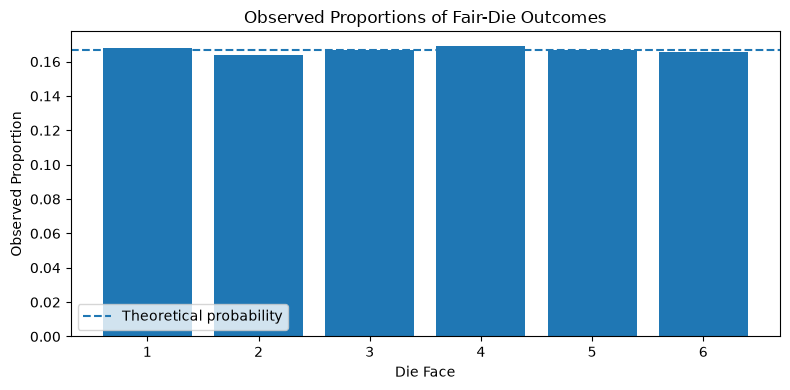

In [13]:
number_of_die_rolls = 12_000
theoretical_face_probability = 1 / 6

uniform_die_rolls = rng.integers(
    low=1,
    high=7,
    size=number_of_die_rolls
)

die_face_values = np.arange(1, 7)

die_face_counts = np.bincount(
    uniform_die_rolls,
    minlength=7
)[1:]

die_face_proportions = (
    die_face_counts / number_of_die_rolls
)

print(
    f"{'Die Face':>10}"
    f"{'Count':>12}"
    f"{'Proportion':>16}"
)

for face, count, proportion in zip(
    die_face_values,
    die_face_counts,
    die_face_proportions
):
    print(
        f"{face:>10}"
        f"{count:>12,}"
        f"{proportion:>16.4f}"
    )

print(
    "\nTheoretical probability for each face: "
    f"{theoretical_face_probability:.4f}"
)

plt.figure(figsize=(8, 4))

plt.bar(
    die_face_values,
    die_face_proportions
)

plt.axhline(
    theoretical_face_probability,
    linestyle="--",
    label="Theoretical probability"
)

plt.title("Observed Proportions of Fair-Die Outcomes")
plt.xlabel("Die Face")
plt.ylabel("Observed Proportion")
plt.xticks(die_face_values)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The observed proportions of the six die faces should be close to the
theoretical probability of approximately 0.1667.

The proportions are not expected to be identical because random
variation remains present in a finite simulation.

The similar bar heights support the assumption that the simulated die
follows a uniform distribution.

However, a dataset that merely looks visually flat is not automatically
uniform. A uniform distribution is defined by the underlying probability
model, not only by the appearance of one finite sample.

## 14. Binomial Distribution

A binomial distribution describes the number of successes in a fixed
number of repeated trials.

It requires four conditions:

1. The number of trials is fixed.
2. Each trial has two possible outcomes.
3. The trials are independent.
4. The probability of success remains constant.

For example, consider 10 fair-coin flips:

- The number of trials is fixed at 10.
- Each trial produces heads or tails.
- The flips are independent.
- The probability of heads remains 0.5.

The binomial random variable counts the number of heads obtained across
the 10 flips.

Its possible values are:

```text
0, 1, 2, ..., 10

Number of trials per experiment: 10
Number of simulated experiments: 20,000
Observed mean number of heads: 4.9517
Theoretical mean number of heads: 5.0000


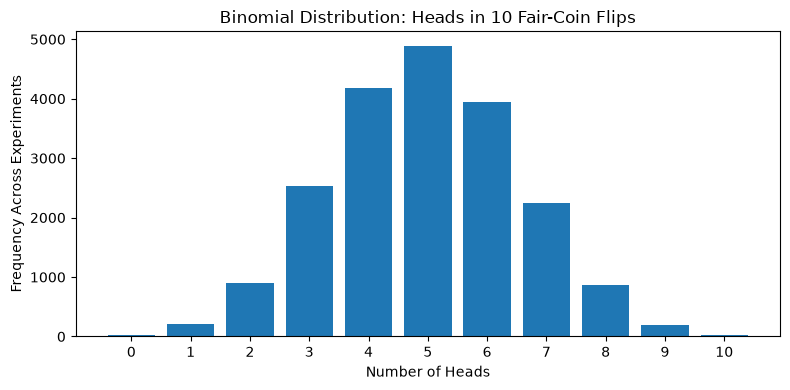

In [14]:
number_of_trials = 10
success_probability = 0.5
number_of_binomial_experiments = 20_000

binomial_success_counts = rng.binomial(
    n=number_of_trials,
    p=success_probability,
    size=number_of_binomial_experiments
)

observed_mean_successes = np.mean(
    binomial_success_counts
)

theoretical_mean_successes = (
    number_of_trials * success_probability
)

possible_success_counts = np.arange(
    number_of_trials + 1
)

success_count_frequencies = np.bincount(
    binomial_success_counts,
    minlength=number_of_trials + 1
)

print(
    f"Number of trials per experiment: "
    f"{number_of_trials}"
)

print(
    f"Number of simulated experiments: "
    f"{number_of_binomial_experiments:,}"
)

print(
    "Observed mean number of heads: "
    f"{observed_mean_successes:.4f}"
)

print(
    "Theoretical mean number of heads: "
    f"{theoretical_mean_successes:.4f}"
)

plt.figure(figsize=(8, 4))

plt.bar(
    possible_success_counts,
    success_count_frequencies
)

plt.title("Binomial Distribution: Heads in 10 Fair-Coin Flips")
plt.xlabel("Number of Heads")
plt.ylabel("Frequency Across Experiments")
plt.xticks(possible_success_counts)
plt.tight_layout()
plt.show()

### Interpretation

The distribution should be concentrated around 5 heads because the
theoretical expected number of successes is:

$$
n \times p = 10 \times 0.5 = 5
$$

Experiments producing approximately 4, 5, or 6 heads should occur more
frequently than experiments producing extreme values such as 0 or 10
heads.

The observed mean number of heads should be close to the theoretical
mean of 5, although a perfect match is not required.

This example demonstrates that the binomial distribution describes the
number of successes across repeated binary trials. It does not describe
the result of only one coin flip.

## 15. Normal Distribution

A normal distribution is a continuous, symmetric, bell-shaped
distribution.

Most values are concentrated near the mean, while values far from the
mean occur less frequently.

A normal distribution is mainly defined by:

- The **mean**, which determines the centre.
- The **standard deviation**, which determines the spread.

For this simulation, we choose:

- Theoretical mean: 100.
- Theoretical standard deviation: 15.
- Sample size: 10,000.

We will generate the sample using NumPy and compare the sample mean and
standard deviation with the chosen theoretical values.

We will also plot a histogram to inspect whether the sample displays the
expected bell shape.

A finite random sample will not form a mathematically perfect curve.

Sample size: 10,000
Theoretical mean: 100.0000
Sample mean: 100.0090
Absolute mean difference: 0.0090

Theoretical standard deviation: 15.0000
Sample standard deviation: 14.9896
Absolute standard-deviation difference: 0.0104


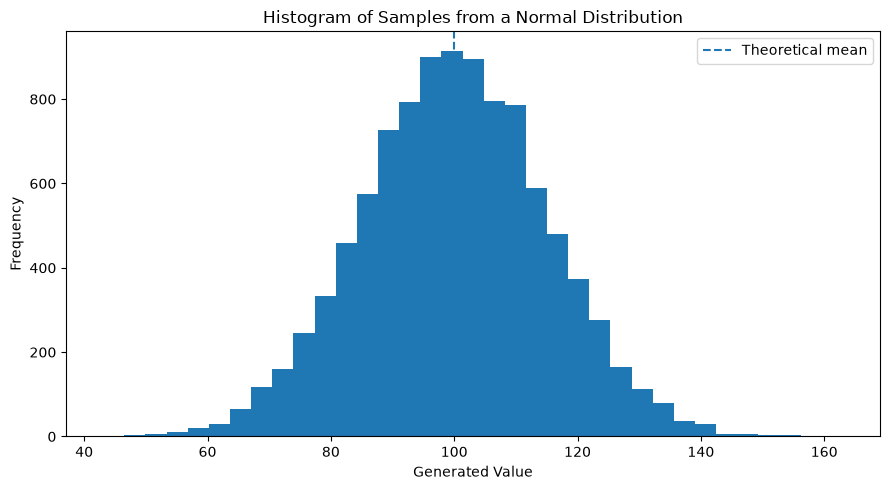

In [15]:
theoretical_normal_mean = 100
theoretical_normal_standard_deviation = 15
normal_sample_size = 10_000

normal_samples = rng.normal(
    loc=theoretical_normal_mean,
    scale=theoretical_normal_standard_deviation,
    size=normal_sample_size
)

sample_normal_mean = np.mean(normal_samples)

sample_normal_standard_deviation = np.std(
    normal_samples
)

mean_difference = abs(
    sample_normal_mean
    - theoretical_normal_mean
)

standard_deviation_difference = abs(
    sample_normal_standard_deviation
    - theoretical_normal_standard_deviation
)

print(
    f"Sample size: {normal_sample_size:,}"
)

print(
    "Theoretical mean: "
    f"{theoretical_normal_mean:.4f}"
)

print(
    "Sample mean: "
    f"{sample_normal_mean:.4f}"
)

print(
    "Absolute mean difference: "
    f"{mean_difference:.4f}"
)

print(
    "\nTheoretical standard deviation: "
    f"{theoretical_normal_standard_deviation:.4f}"
)

print(
    "Sample standard deviation: "
    f"{sample_normal_standard_deviation:.4f}"
)

print(
    "Absolute standard-deviation difference: "
    f"{standard_deviation_difference:.4f}"
)

plt.figure(figsize=(9, 5))

plt.hist(
    normal_samples,
    bins=35
)

plt.axvline(
    theoretical_normal_mean,
    linestyle="--",
    label="Theoretical mean"
)

plt.title("Histogram of Samples from a Normal Distribution")
plt.xlabel("Generated Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The histogram should display an approximately symmetric bell shape, with
most observations concentrated around the theoretical mean of 100.

The sample mean should be close to 100, and the sample standard deviation
should be close to 15.

Small differences are expected because the generated data is a finite
random sample rather than the complete theoretical distribution.

The histogram will not be perfectly smooth or perfectly symmetric.
Random fluctuations between bins are normal.

This experiment demonstrates the general shape and behaviour of a normal
distribution. It does not mean that every real-world variable follows a
normal distribution. The shape of real data must be inspected rather
than assumed.

## 16. Comparison of the Three Distributions

| Feature | Uniform | Binomial | Normal |
|---|---|---|---|
| Main idea | Outcomes are equally likely | Counts successes across repeated trials | Values cluster around a mean |
| Value type in this notebook | Discrete die outcomes | Discrete success counts | Continuous numeric values |
| Example | One fair-die roll | Heads in 10 coin flips | Measurement values |
| Main parameters | Possible outcome range | Number of trials and success probability | Mean and standard deviation |
| Typical visual shape | Similar probabilities across outcomes | Highest probabilities often near the expected count | Symmetric bell shape |

The distributions answer different questions and should not be treated
as interchangeable.

## 17. Summary of Results

The simulations were generally consistent with the theoretical
probabilities.

The proportion of heads in the large coin-flip experiment was close to
0.5, while the smaller experiments showed more variation. This showed
why estimates usually become more stable when the number of trials
increases.

The conditional-probability simulation also produced a result close to
the manual calculation. The example made it clear that the condition
changes the group used in the denominator.

The three distribution examples represented different types of random
behaviour:

- The fair-die outcomes had approximately equal proportions.
- The binomial simulation was concentrated around the expected number
  of heads.
- The normal sample formed an approximate bell shape around its chosen
  mean.

## 18. Relevance to Machine Learning

Probability is useful in machine learning because predictions are often
made under uncertainty.

For example, a classification model may estimate the probability of a
class given a set of observed features. This is closely related to
conditional probability.

Bayes' theorem is also relevant because it explains how a probability
can be updated after observing new evidence. This idea is used in the
Naive Bayes classifier.

Probability distributions are useful for describing different kinds of
data and random behaviour. A binomial distribution can represent
repeated binary outcomes, while a normal distribution is often used when
working with measurement variation or noise.

These concepts provide mathematical foundations for later machine-
learning topics, but no model was trained in this notebook.

## 19. Conclusion

This work introduced probability as a way to describe and calculate
uncertainty.

I applied the complement, addition, and multiplication rules, and then
used conditional probability to calculate an event within a restricted
group. Bayes' theorem showed how a prior probability can be updated after
observing evidence.

The NumPy simulations helped compare theoretical probability with
experimental results. They also demonstrated the main characteristics of
the uniform, binomial, and normal distributions.

The most important lesson from these experiments is that simulated
results do not need to match theoretical probabilities exactly. With a
large number of trials, however, the observed results generally become
more stable and remain close to the expected values.